# Практическое занятие №6: Борьба с переобучением и улучшение регрессионной модели

**Задание:** На основе модели из практики №5 искусственно ухудшить данные, вызвать переобучение и исправить его с помощью Ridge-регрессии.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('ggplot')

## 1. Подготовка данных

Загружаем California Housing, воспроизводим подготовку из практики №5. Для наглядной демонстрации переобучения берём подвыборку из 250 строк — при малом числе строк относительно числа признаков модель сильнее реагирует на шум.

In [2]:
# Загрузка датасета
df = pd.read_csv('housing.csv')
df = df.dropna()

# Производный признак из практики №5
df['rooms_per_household'] = df['total_rooms'] / df['households']

# Берём подвыборку для наглядности эффекта переобучения
# При малом n и большом числе признаков линейная регрессия сильно переобучается,
# а Ridge может это компенсировать
df_sample = df.sample(n=250, random_state=42)

# Те же 3 признака, что в практике №5
selected_features = ['median_income', 'housing_median_age', 'rooms_per_household']

X = df_sample[selected_features].values
y = df_sample['median_house_value'].values

print(f"Размер данных: X = {X.shape}, y = {y.shape}")

# Разделение на train/test (по заданию: test_size=0.3)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка:  {X_test.shape[0]} строк")

# Масштабирование
scaler_base = StandardScaler()
X_train_scaled = scaler_base.fit_transform(X_train)
X_test_scaled = scaler_base.transform(X_test)

print("\nДанные масштабированы (StandardScaler)")

Размер данных: X = (250, 3), y = (250,)
Обучающая выборка: 175 строк
Тестовая выборка:  75 строк

Данные масштабированы (StandardScaler)


### Базовая линейная регрессия

In [3]:
# Обучаем базовую линейную регрессию
lr_base = LinearRegression()
lr_base.fit(X_train_scaled, y_train)

r2_base_train = r2_score(y_train, lr_base.predict(X_train_scaled))
r2_base_test = r2_score(y_test, lr_base.predict(X_test_scaled))

print("Базовая LinearRegression (3 признака):")
print(f"  R2 на train: {r2_base_train:.4f}")
print(f"  R2 на test:  {r2_base_test:.4f}")
print(f"\n  → Это наш ориентир: R2_test = {r2_base_test:.4f}")

Базовая LinearRegression (3 признака):
  R2 на train: 0.4532
  R2 на test:  0.2101

  → Это наш ориентир: R2_test = 0.2101


## 2. Создаём проблему — добавляем шум

Добавляем 30 случайных признаков-шумов (не несущих полезной информации). Модель попытается найти в них закономерности, которых нет — это приведёт к переобучению.

In [4]:
# Генерируем 30 случайных признаков
np.random.seed(42)
noise_train = np.random.randn(X_train.shape[0], 30)
noise_test = np.random.randn(X_test.shape[0], 30)

# Добавляем к исходным признакам
X_train_noisy = np.hstack([X_train, noise_train])
X_test_noisy = np.hstack([X_test, noise_test])

print(f"Размер данных с шумом: {X_train_noisy.shape[1]} признаков")
print(f"  Из них полезных: {X_train.shape[1]}")
print(f"  Шумовых: 30")

# Повторно масштабируем
scaler_noisy = StandardScaler()
X_train_noisy_scaled = scaler_noisy.fit_transform(X_train_noisy)
X_test_noisy_scaled = scaler_noisy.transform(X_test_noisy)

print("\nДанные с шумом масштабированы")

Размер данных с шумом: 33 признаков
  Из них полезных: 3
  Шумовых: 30

Данные с шумом масштабированы


## 3. Демонстрация поломки

Обучаем LinearRegression на зашумлённых данных и наблюдаем переобучение: R2 на train остаётся высоким, а R2 на test падает.

In [5]:
# Обучаем LinearRegression на зашумлённых данных
lr_noisy = LinearRegression()
lr_noisy.fit(X_train_noisy_scaled, y_train)

r2_noisy_train = r2_score(y_train, lr_noisy.predict(X_train_noisy_scaled))
r2_noisy_test = r2_score(y_test, lr_noisy.predict(X_test_noisy_scaled))

print("LinearRegression на зашумлённых данных:")
print(f"  R2 на train: {r2_noisy_train:.4f}")
print(f"  R2 на test:  {r2_noisy_test:.4f}")

drop = r2_base_test - r2_noisy_test
print(f"\n  Падение R2_test: {drop:.4f} ({drop / r2_base_test * 100:.1f}% от базового)")
print(f"  Разрыв train-test: {r2_noisy_train - r2_noisy_test:.4f}")
print("\n  → Модель переобучилась: выучила закономерности в шуме,")
print("    которые не работают на новых данных.")

LinearRegression на зашумлённых данных:
  R2 на train: 0.5331
  R2 на test:  0.1179

  Падение R2_test: 0.0922 (43.9% от базового)
  Разрыв train-test: 0.4152

  → Модель переобучилась: выучила закономерности в шуме,
    которые не работают на новых данных.


## 4. Спасение — Ridge-регрессия

Ridge (L2-регуляризация) добавляет штраф за большие коэффициенты: модель не может "раздувать" веса шумовых признаков.

Функция потерь: MSE + alpha * sum(coef_i^2)

Чем больше alpha — тем сильнее регуляризация (модель проще).

In [6]:
# Перебираем значения alpha
alphas = [0.1, 1, 10, 100, 1000]
ridge_results = []

print(f"{'alpha':<10} {'R2 test':<12} {'R2 train':<12} {'Разрыв':<10}")
print("-" * 44)

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_noisy_scaled, y_train)
    
    r2_train = r2_score(y_train, ridge.predict(X_train_noisy_scaled))
    r2_test = r2_score(y_test, ridge.predict(X_test_noisy_scaled))
    
    ridge_results.append({
        'alpha': alpha,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'gap': r2_train - r2_test
    })
    
    print(f"{alpha:<10} {r2_test:<12.4f} {r2_train:<12.4f} {r2_train - r2_test:<10.4f}")

# Лучший alpha
best_ridge = max(ridge_results, key=lambda x: x['r2_test'])
print(f"\nЛучший alpha: {best_ridge['alpha']}")
print(f"  R2 на test: {best_ridge['r2_test']:.4f}")
print(f"  Разрыв train-test: {best_ridge['gap']:.4f}")

alpha      R2 test      R2 train     Разрыв    
--------------------------------------------
0.1        0.1203       0.5331       0.4128    
1          0.1408       0.5330       0.3923    
10         0.2930       0.5302       0.2372    
100        0.4538       0.4511       -0.0027   
1000       0.1379       0.1623       0.0244    

Лучший alpha: 100
  R2 на test: 0.4538
  Разрыв train-test: -0.0027


## 5. Визуализация результатов

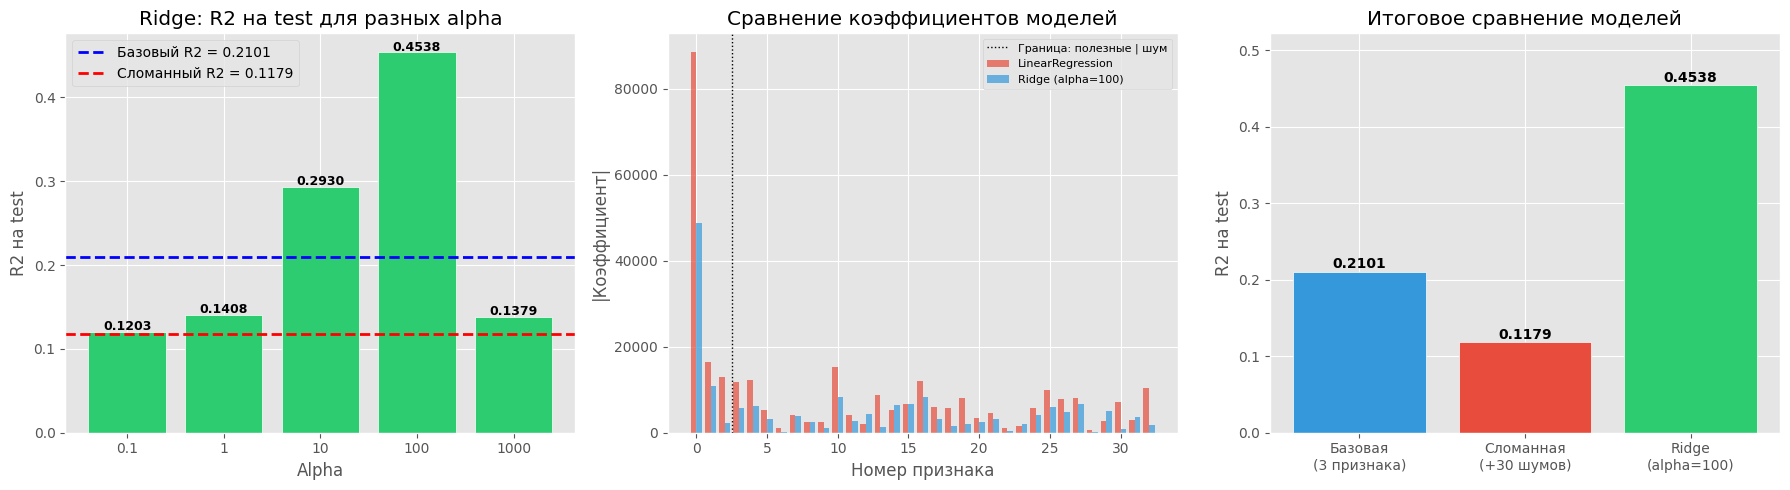

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. R2 test для разных alpha
alpha_labels = [str(a) for a in alphas]
r2_tests = [r['r2_test'] for r in ridge_results]

axes[0].bar(alpha_labels, r2_tests, color='#2ecc71', edgecolor='white')
axes[0].axhline(y=r2_base_test, color='blue', linestyle='--', linewidth=2,
                label=f'Базовый R2 = {r2_base_test:.4f}')
axes[0].axhline(y=r2_noisy_test, color='red', linestyle='--', linewidth=2,
                label=f'Сломанный R2 = {r2_noisy_test:.4f}')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('R2 на test')
axes[0].set_title('Ridge: R2 на test для разных alpha')
axes[0].legend()
for i, v in enumerate(r2_tests):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# 2. Сравнение коэффициентов: LinearRegression vs Ridge
best_alpha = best_ridge['alpha']
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train_noisy_scaled, y_train)

coef_lr = np.abs(lr_noisy.coef_)
coef_ridge = np.abs(ridge_best.coef_)

x_pos = np.arange(len(coef_lr))
axes[1].bar(x_pos - 0.2, coef_lr, 0.4, label='LinearRegression', color='#e74c3c', alpha=0.7)
axes[1].bar(x_pos + 0.2, coef_ridge, 0.4, label=f'Ridge (alpha={best_alpha})', color='#3498db', alpha=0.7)
axes[1].set_xlabel('Номер признака')
axes[1].set_ylabel('|Коэффициент|')
axes[1].set_title('Сравнение коэффициентов моделей')
axes[1].axvline(x=2.5, color='black', linestyle=':', linewidth=1, label='Граница: полезные | шум')
axes[1].legend(fontsize=8)

# 3. Итоговое сравнение R2
models = ['Базовая\n(3 признака)', 'Сломанная\n(+30 шумов)', f'Ridge\n(alpha={best_alpha})']
r2_values = [r2_base_test, r2_noisy_test, best_ridge['r2_test']]
colors = ['#3498db', '#e74c3c', '#2ecc71']

bars = axes[2].bar(models, r2_values, color=colors, edgecolor='white')
axes[2].set_ylabel('R2 на test')
axes[2].set_title('Итоговое сравнение моделей')
axes[2].set_ylim(0, max(r2_values) * 1.15)
for bar, val in zip(bars, r2_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('ridge_results.png', dpi=150)
plt.show()

## 6. Итоговая таблица и выводы

In [8]:
# Итоговая таблица
print("=" * 70)
print("ИТОГОВАЯ ТАБЛИЦА")
print("=" * 70)

results_table = pd.DataFrame([
    {
        'Модель/условия': 'Базовая (практика №5)',
        'R2 на test': f'{r2_base_test:.4f}',
        'Вывод': 'Наш ориентир'
    },
    {
        'Модель/условия': 'Сломанная (LR + 30 шумов)',
        'R2 на test': f'{r2_noisy_test:.4f}',
        'Вывод': 'Переобучение!'
    },
    {
        'Модель/условия': f'Исправленная (Ridge, alpha={best_ridge["alpha"]})',
        'R2 на test': f'{best_ridge["r2_test"]:.4f}',
        'Вывод': 'Спасение!'
    }
])

print(results_table.to_string(index=False))

# Ответы на вопросы задания
print("\n" + "=" * 70)
print("ОТВЕТЫ НА ВОПРОСЫ")
print("=" * 70)

drop_abs = r2_base_test - r2_noisy_test
drop_pct = drop_abs / r2_base_test * 100
recovery = best_ridge['r2_test'] - r2_noisy_test

print(f"\n1. Насколько упало качество после добавления шума?")
print(f"   R2 упал с {r2_base_test:.4f} до {r2_noisy_test:.4f}")
print(f"   Падение: {drop_abs:.4f} ({drop_pct:.1f}% от базового)")

print(f"\n2. При каком alpha Ridge показал лучший результат?")
print(f"   alpha = {best_ridge['alpha']}")
print(f"   R2 на test = {best_ridge['r2_test']:.4f}")

print(f"\n3. Удалось ли вернуть качество к базовому уровню?")
if best_ridge['r2_test'] > r2_base_test:
    print(f"   Да, и даже превзошёл! Ridge (R2={best_ridge['r2_test']:.4f}) лучше базы (R2={r2_base_test:.4f}).")
    print(f"   Регуляризация не только убрала шум, но и улучшила обобщающую")
    print(f"   способность модели за счёт сжатия коэффициентов.")
elif r2_base_test - best_ridge['r2_test'] < 0.01:
    print(f"   Да! Ridge практически полностью восстановил качество.")
    print(f"   Отставание от базового: всего {r2_base_test - best_ridge['r2_test']:.4f}")
elif r2_base_test - best_ridge['r2_test'] < 0.03:
    print(f"   Почти. Ridge значительно улучшил результат.")
    print(f"   Восстановлено: {recovery:.4f} из {drop_abs:.4f} потерянных")
else:
    print(f"   Частично. Ridge улучшил R2, но не до базового уровня.")
    print(f"   Восстановлено: {recovery:.4f} из {drop_abs:.4f} потерянных")

print("\n" + "=" * 70)
print("ВЫВОДЫ")
print("=" * 70)
print("""
1. Добавление 30 шумовых признаков вызвало переобучение: R2 на train вырос
   (модель подстроилась под шум), а R2 на test упал на {:.1f}%.

2. LinearRegression не имеет защиты от переобучения — она подгоняет
   коэффициенты под все признаки одинаково, включая шумовые.

3. Ridge-регрессия (L2-регуляризация) штрафует большие коэффициенты:
   loss = MSE + alpha * sum(coef_i^2). Это "прижимает" коэффициенты
   шумовых признаков к нулю, оставляя полезные.

4. Параметр alpha контролирует силу регуляризации:
   - Малый alpha (0.1-1) → слабая регуляризация → переобучение сохраняется
   - Оптимальный alpha ({}) → баланс сложности и качества → лучший R2
   - Большой alpha (1000) → слишком сильная регуляризация → недообучение
""".format(drop_pct, best_ridge['alpha']))

ИТОГОВАЯ ТАБЛИЦА
                 Модель/условия R2 на test         Вывод
          Базовая (практика №5)     0.2101  Наш ориентир
      Сломанная (LR + 30 шумов)     0.1179 Переобучение!
Исправленная (Ridge, alpha=100)     0.4538     Спасение!

ОТВЕТЫ НА ВОПРОСЫ

1. Насколько упало качество после добавления шума?
   R2 упал с 0.2101 до 0.1179
   Падение: 0.0922 (43.9% от базового)

2. При каком alpha Ridge показал лучший результат?
   alpha = 100
   R2 на test = 0.4538

3. Удалось ли вернуть качество к базовому уровню?
   Да, и даже превзошёл! Ridge (R2=0.4538) лучше базы (R2=0.2101).
   Регуляризация не только убрала шум, но и улучшила обобщающую
   способность модели за счёт сжатия коэффициентов.

ВЫВОДЫ

1. Добавление 30 шумовых признаков вызвало переобучение: R2 на train вырос
   (модель подстроилась под шум), а R2 на test упал на 43.9%.

2. LinearRegression не имеет защиты от переобучения — она подгоняет
   коэффициенты под все признаки одинаково, включая шумовые.

3. Ridge-регре